In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer


In [2]:
train = pd.read_csv("/content/train.csv")
test  = pd.read_csv("/content/test.csv")



In [3]:
train.drop(columns=['id'],inplace=True)

In [4]:
col='Age'
df_log = train.copy()
df_log[col + "_log"] = np.log1p(df_log[col]+1)

In [5]:
train.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.6000,1.2500,0.5750,43.700754,15.025235,10.262519,13.324265,17.0
1,M,1.5750,1.1625,0.3750,32.417653,12.927372,6.208540,8.930093,20.0
2,F,1.6125,1.2750,0.4375,34.373769,14.784264,9.142714,10.772810,10.0
3,M,1.2250,0.9875,0.3250,18.455524,8.037083,3.926406,4.819415,9.0
4,I,1.3750,1.0250,0.3875,22.736299,9.879801,5.513978,6.945627,10.0


In [6]:
df_log.drop(columns=['Age'],inplace=True)

In [7]:
df_log.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age_log
0,F,1.6000,1.2500,0.5750,43.700754,15.025235,10.262519,13.324265,2.944439
1,M,1.5750,1.1625,0.3750,32.417653,12.927372,6.208540,8.930093,3.091042
2,F,1.6125,1.2750,0.4375,34.373769,14.784264,9.142714,10.772810,2.484907
3,M,1.2250,0.9875,0.3250,18.455524,8.037083,3.926406,4.819415,2.397895
4,I,1.3750,1.0250,0.3875,22.736299,9.879801,5.513978,6.945627,2.484907


In [8]:

X = df_log.drop(columns=["Age_log"])
y = df_log["Age_log"]

In [9]:
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include=object).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: Index(['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight',
       'Viscera Weight', 'Shell Weight'],
      dtype='object')
Categorical columns: Index(['Sex'], dtype='object')


In [10]:
!pip install feature_engine


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 8.4 MB/s eta 0:00:00


In [11]:
numeric_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
         ('log', FunctionTransformer(func=np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ]
)


In [12]:
catagoric_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)


In [13]:
pipeline = ColumnTransformer(
    [
        ('num', numeric_pipe, numerical_cols),
        ('cat', catagoric_pipe, categorical_cols)
    ]
)




In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [15]:
reg_lin=LinearRegression()
reg_dt=DecisionTreeRegressor()
reg_rf=RandomForestRegressor()
reg_gb=GradientBoostingRegressor()
reg_ada=AdaBoostRegressor()
reg_xgb=XGBRegressor()
reg_ada=AdaBoostRegressor()


In [16]:
voting_reg = VotingRegressor(
    estimators=[
        ('lin', reg_lin),
        ('rf', reg_rf),
        ('gb', reg_gb),
    ]
)

In [17]:
stacking_reg = StackingRegressor(
    estimators=[
        ('lin', reg_lin),
        ('dt',reg_dt),
        ('rf', reg_rf),
        ('gb', reg_gb),
        ('ada',reg_ada),
        ('xgb',reg_xgb)
    ]
)

In [18]:
# model Train
import warnings
warnings.filterwarnings('ignore')

model_train = {
    'Linear Regression': reg_lin,
    'Decision Tree': reg_dt,
    'Random Forest': reg_rf,
    'Gradient Boost': reg_gb,
    'AdaBoost': reg_ada,
    'Voting Regressor': voting_reg,
    'Stacking Regressor': stacking_reg
}

In [19]:
# Store results
results = []

for name, model in model_train.items():
    pipe = Pipeline([
        ('preprocessing', pipeline),
        ('regressor', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        'Model Name': name,
        'R2 Score': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

# Convert results to DataFrame and sort by R2 Score
result_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print(result_df)

           Model Name  R2 Score       MAE       MSE      RMSE
0  Stacking Regressor  0.693178  0.106343  0.020490  0.143144
1    Voting Regressor  0.690977  0.106959  0.020637  0.143657
2      Gradient Boost  0.687191  0.106723  0.020890  0.144534
3   Linear Regression  0.672278  0.110414  0.021886  0.147939
4       Random Forest  0.671228  0.110512  0.021956  0.148176
5       Decision Tree  0.363278  0.149394  0.042522  0.206208
6            AdaBoost  0.321914  0.184575  0.045284  0.212801


Best Model: Stacking Regressor
R² Score: 0.6936
Mean_absolute_error: 0.1064
Mean_squared_error: 0.0205
RMSE: 0.1430


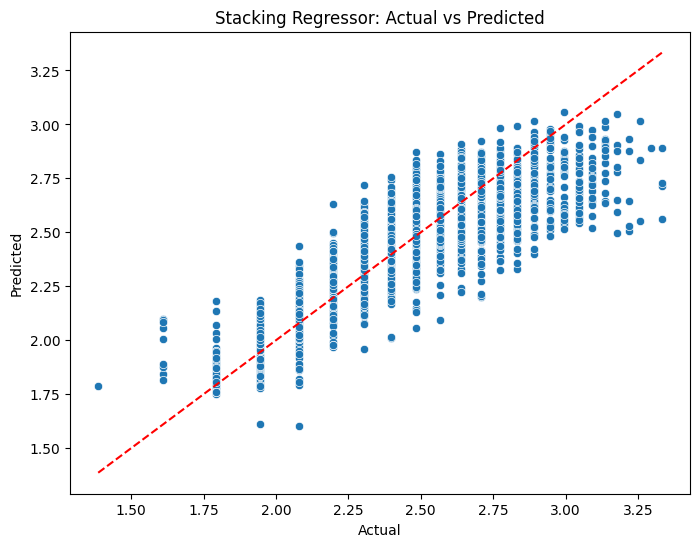

In [20]:
best_model_name = result_df.iloc[0]['Model Name']
best_model_obj = model_train[best_model_name]
final_pipe = Pipeline([
    ('Combine_pipe', pipeline),
    ('regressor', best_model_obj)
])

final_pipe.fit(X_train, y_train)
y_final_pred = final_pipe.predict(X_test)

r2 = r2_score(y_test, y_final_pred)
mae = mean_absolute_error(y_test, y_final_pred)
mse = mean_squared_error(y_test, y_final_pred)
rmse = np.sqrt(mse)

print(f"Best Model: {best_model_name}")
print(f"R² Score: {r2:.4f}")
print(f"Mean_absolute_error: {mae:.4f}")
print(f"Mean_squared_error: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_final_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_model_name}: Actual vs Predicted')
plt.show()

In [21]:
stk_reg_pipe = Pipeline([
        ('preprocessing', pipeline),
        ('regressor', stacking_reg)
    ])
stk_reg_pipe.fit(X_train, y_train)
y_pred = stk_reg_pipe.predict(X_test)

In [22]:
y_submission_pred_log = final_pipe.predict(test)

y_submission_pred = np.expm1(y_submission_pred_log) - 1

y_submission_pred = np.maximum(0, y_submission_pred)

submission_df = pd.DataFrame(
    {
        'id': test['id'],
        'Age': y_submission_pred
    }
)
submission_df.to_csv('submission.csv', index=False)
print(submission_df)

         id        Age
0     15000  13.355562
1     15001  12.275208
2     15002   9.401906
3     15003  11.082262
4     15004   9.195206
...     ...        ...
9995  24995  10.854751
9996  24996  10.008017
9997  24997   9.392279
9998  24998  10.818108
9999  24999   7.130521

[10000 rows x 2 columns]


In [23]:
stk_cross_val=cross_val_score(stk_reg_pipe,X_train,y_train,cv=5,scoring='r2')


In [24]:
stk_cross_val

array([0.68577496, 0.6793572 , 0.68386008, 0.67095506, 0.71792867])

In [25]:
stk_cross_val.mean()

np.float64(0.6875751921689155)

In [26]:
stk_cross_val.std()

np.float64(0.01601337324263631)

In [27]:
param_grid = {
    'regressor__rf__n_estimators': [100, 200],
    'regressor__rf__max_depth': [10, 20],
    'regressor__gb__n_estimators': [100, 200],
    'regressor__gb__max_depth': [10, 20]
}

In [ ]:
grid_search = GridSearchCV(
    estimator= stk_reg_pipe,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('log',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight',
       'Viscera Weight', 'Shell Weight'],
      dtype='object')),
                                                                        (...
                                                                                    max_leaves=None,
                                                                                    min_child_weight=None,
                                                                                    missing=nan,
                                                                                    monotone_constraints=None,
                                                                                    multi_strategy=None,
                                                                                    n_estimators=None,
                                                                                    n_jobs=None,
                                                                                    num_parallel_tree=None, ...))]))]),
             n_jobs=-1,
             param_grid={'regressor__gb__max_depth': [10, 20],
                         'regressor__gb__n_estimators': [100, 200],
                         'regressor__rf__max_depth': [10, 20],
                         'regressor__rf__n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [ ]:
y_pred = grid_search.predict(X_test)
print(grid_search.best_score_)
print(grid_search.best_params_)

0.6861463238828197
{'regressor__gb__max_depth': 20, 'regressor__gb__n_estimators': 200, 'regressor__rf__max_depth': 10, 'regressor__rf__n_estimators': 200}


In [ ]:
print("R2 ",r2_score(y_test,y_pred))
print("MAE ",mean_absolute_error(y_test,y_pred))
print("MSE ",mean_squared_error(y_test,y_pred))
print("RMSE ",np.sqrt(mean_squared_error(y_test,y_pred)))

R2  0.6918163984221183
MAE  0.10680274067104382
MSE  0.02058122394470049
RMSE  0.1434615765447337
